<a href="https://colab.research.google.com/github/TanyashaVoron/stock_market_analysis/blob/main/%D0%9F%D1%80%D0%BE%D0%B2%D0%B5%D1%80%D0%BA%D0%B0_%D0%BC%D0%BE%D0%B4%D0%B5%D0%BB%D0%B5%D0%B9_%D0%BD%D0%B0_%D0%B0%D0%B4%D0%B5%D0%BA%D0%B2%D0%B0%D1%82%D0%BD%D0%BE%D1%81%D1%82%D1%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* 1) Нужно через уравнение регрессии подобрать начальное значение x и y
* 2) берем первые n значений и находим оптимальные коэффициенты минимум суммы квадратов остатков по модели
* 3) проверяем адекватность модели:
 * 3.1) случайность остатков
 * 3.2) нормальность остатков - Критерий пинсона хи квадрат
 * 3.3) отсутствие автокорреляции - Статистика Дарвина Уотсона

In [62]:
data_main = [272.92, 267.8, 267.88, 268.07, 268.49, 266.29, 259.31, 264.25, 264.09, 263.39, 262.4, 260.86, 259.98, 256.94, 261.28, 262.03, 259.5, 256.57, 257.19, 258.21, 255.42, 252.01, 252.64, 246.35, 242.56, 242.66, 241.45]

# Общий вывод данных - график + таблица

In [10]:
def print_data(name, alp_data_plot, alp_data_table):
  print_plot(alp_data_plot, name)
  print_table(alp_data_table)

## Построение графиков



In [11]:
import matplotlib.pyplot as plt

def print_plot(alp_data, name):
    plt.figure(figsize=(20, 5))  # Установка размера графика (ширина, высота)

    for label, data in alp_data.items():
        plt.plot(data, label=label)
        #, marker='o')

        # Подписываем значения в точках
        # for i, value in enumerate(data):
            # plt.text(i, value, f'{value:.2f}', fontsize=9, ha='center', va='bottom')

    # Настройка осей
    plt.xticks(ticks=range(len(data)))  # Отметки по оси X от 0 до n
    plt.yticks()  # Отметри на оси У


    plt.legend(
        bbox_to_anchor=(1.05, 1),  # Положение легенды: справа от графика
        loc='upper left',          # Выравнивание легенды относительно bbox_to_anchor
        borderaxespad=0.           # Расстояние между легендой и графиком
    )

    plt.tight_layout(rect=[0, 0, 0.85, 1])  # Оставляем место для легенды справа


    # Добавление легенды и отображение графика
    plt.legend()
    plt.title(name)  # Заголовок графика
    plt.grid()  # Добавление сетки
    plt.show()

## Построение таблиц

In [12]:
import pandas as pd
from tabulate import tabulate

def print_table(data_dict):
    for key in data_dict:
        data_dict[key] = [round(num, 3) for num in data_dict[key]]

    # Определяем максимальную длину массивов
    max_length = max(len(values) for values in data_dict.values())

    # Создаем новый словарь с дополненными массивами
    padded_data = {key: values + [None] * (max_length - len(values)) for key, values in data_dict.items()}

    # Создаем DataFrame из дополненного словаря
    df = pd.DataFrame(padded_data)

    # Добавляем нумерацию строк
    df.index.name = 'Номер строки'

    # Выводим таблицу
    print(tabulate(df, headers='keys', tablefmt='pretty'))

## Процент от основного датасета

In [13]:
def prosent(main_data, new_data):
  max_len_data = max(len(main_data), len(new_data))
  return [
        round(((main_data[i] / new_data[i] - 1) * 100), 2) if new_data[i] != 0 else None
        for i in range(max_len_data)
    ]

# 0) Общие функции

In [113]:
# Функция для расчета ошибки (MSE)
def calculate_error(actual, forecast):
    """
    Рассчитывает среднеквадратичную ошибку (MSE).

    :param actual: Список фактических значений
    :param forecast: Список прогнозируемых значений
    :return: MSE
    """
    if len(actual) != len(forecast):
        raise ValueError("Длины фактических и прогнозируемых данных не совпадают.")

    residuals = np.array(actual) - np.array(forecast)
    mse = np.mean(residuals ** 2)
    return mse

# Функция проверки адекватности модели
def check_model_adequacy(data, forecasts):
    """
    Проверяет адекватность модели по трем критериям:
    1. Случайность остатков.
    2. Нормальность остатков (критерий хи-квадрат Пирсона).
    3. Отсутствие автокорреляции (статистика Дарбина-Уотсона).

    :param data: Исходные данные (временной ряд)
    :param forecasts: Прогнозы модели (только исторические данные)
    :return: Результаты проверок (случайность, нормальность, автокорреляция)
    """
    # Вычисление остатков
    residuals = np.array(data) - np.array(forecasts)

    # 1. Проверка случайности остатков (тест на поворотные точки)
    turning_points = sum(
        1 for i in range(1, len(residuals) - 1)
        if (residuals[i] > residuals[i - 1] and residuals[i] > residuals[i + 1]) or
           (residuals[i] < residuals[i - 1] and residuals[i] < residuals[i + 1])
    )
    expected_turning_points = (2 * (len(residuals) - 2)) / 3
    variance_turning_points = (16 * len(residuals) - 29) / 90
    z_score = abs((turning_points - expected_turning_points) / np.sqrt(variance_turning_points))
    randomness = z_score < 1.96  # Если z_score < 1.96, остатки случайны

    # 2. Проверка нормальности остатков (критерий хи-квадрат Пирсона)
    num_bins = int(np.sqrt(len(residuals)))  # Количество интервалов
    hist, bin_edges = np.histogram(residuals, bins=num_bins)
    observed_freq = hist  # Наблюдаемые частоты
    expected_freq = len(residuals) / num_bins  # Ожидаемые частоты
    chi_square_stat = sum((observed_freq - expected_freq) ** 2 / expected_freq)
    degrees_of_freedom = num_bins - 1
    p_value_chi_square = chi2.sf(chi_square_stat, degrees_of_freedom)
    normality = p_value_chi_square > 0.05  # Если p-value > 0.05, остатки нормально распределены

    # 3. Проверка отсутствия автокорреляции (статистика Дарбина-Уотсона)
    dw_stat = sum((residuals[i] - residuals[i - 1]) ** 2 for i in range(1, len(residuals))) / sum(r ** 2 for r in residuals)
    autocorrelation = 1.5 < dw_stat < 2.5  # Если DW ∈ [1.5, 2.5], автокорреляции нет

    # return randomness, z_score, normality, p_value_chi_square, autocorrelation, dw_stat

    print('Проверка адекватности модели')
    print(f'    1. Проверка случайности остатков - Z-score: {z_score:.2f}, Результат: {randomness}')
    print(f'    2. Проверка нормальности остатков (критерий хи-квадрат Пирсона) - p-value: {p_value_chi_square:.4f}, Результат: {normality}')
    print(f'    3. Проверка отсутствия автокорреляции (статистика Дарбина-Уотсона) - DW: {dw_stat:.2f}, Результат: {autocorrelation}')
    print(f'Итого: {randomness * normality * autocorrelation}')

In [115]:
# Функция для поиска оптимальных коэффициентов alpha - для алгоритма эксп и брауна
def find_optimal_alpha(data, model_func, steps=1, step_size=0.1):
    """
    Находит оптимальное значение параметра alpha путем перебора значений от 0 до 1 с шагом 0.01.

    :param data: Временной ряд
    :param model_func: Функция модели прогнозирования
    :param steps: Количество шагов для прогноза в будущее
    :return: Оптимальное значение alpha и соответствующая ошибка
    """
    best_alpha = None
    best_error = float('inf')  # Начальное значение ошибки (бесконечность)

    for alpha in np.arange(0.01, 1.01, 0.01):  # Перебор значений alpha от 0.01 до 1 с шагом 0.01
        # Прогнозирование с текущим alpha
        forecasts = exponential_smoothing(data, alpha, steps=steps)

        # Выделяем прогнозы на будущие шаги
        future_forecasts = forecasts[-steps:]

        # Вычисление ошибки только для прогнозов на будущие шаги
        error = calculate_error(data[-steps:], future_forecasts)

        # Обновление лучшего значения alpha
        if error < best_error:
            best_error = error
            best_alpha = alpha

    return best_alpha, best_error


# Функция для поиска оптимальных коэффициентов alpha, betta - для алгоритма Хольта
def find_optimal_alpha_betta(data, steps=1, step_size=0.1):
    """
    Находит оптимальные значения коэффициентов методом полного перебора.

    :param data: Список данных (временной ряд)
    :param steps: Количество шагов для прогноза в будущее
    :param step_size: Шаг перебора значений коэффициентов (по умолчанию 0.1)
    :return: Оптимальные значения коэффициентов
    """
    best_params = None
    min_error = float('inf')  # Минимальная ошибка (сумма квадратов остатков)

    # Генерируем список значений для каждого параметра
    param_values = [np.arange(0 + step_size, 1, step_size) for _ in range(2)]

    # Перебираем все возможные комбинации параметров
    for params in product(*param_values):  # Все комбинации параметров
        alpha, beta = params

        # Вычисляем прогнозы с текущими параметрами
        forecasts = double_exponential_smoothing(data, alpha, beta, steps=steps)

        # Вычисляем ошибку только для прогнозов на будущие шаги
        error = calculate_error(data[-steps:], forecasts[-steps:])

        # Обновляем лучшие параметры, если текущая ошибка меньше минимальной
        if error < min_error:
            min_error = error
            best_params = params

    return best_params, min_error

from itertools import product
import numpy as np

# Функция для поиска оптимальных коэффициентов alpha, beta, gamma - для алгоритма Бокса-Дженкинса
def find_optimal_alpha_beta_gamma(data, model_func, steps=1, step_size=0.1, control_limit_max=1):
    """
    Находит оптимальные значения коэффициентов методом полного перебора.

    :param data: Список данных (временной ряд)
    :param model_func: Функция модели прогнозирования
    :param steps: Количество шагов для прогноза в будущее
    :param step_size: Шаг перебора значений коэффициентов (по умолчанию 0.1)
    :return: Оптимальные значения коэффициентов и минимальная ошибка
    """
    best_params = None
    min_error = float('inf')  # Минимальная ошибка (сумма квадратов остатков)

    # Генерируем список значений для каждого параметра
    param_values = [np.arange(0 + step_size, control_limit_max, step_size) for _ in range(3)]

    # Перебираем все возможные комбинации параметров
    for params in product(*param_values):  # Все комбинации параметров
        alpha, beta, gamma = params

        # Вычисляем прогнозы с текущими параметрами
        forecasts = model_func(data, alpha, beta, gamma, steps=steps)

        # Вычисляем ошибку только для прогнозов на будущие шаги
        error = calculate_error(data[-steps:], forecasts[-steps:])

        # Обновляем лучшие параметры, если текущая ошибка меньше минимальной
        if error < min_error:
            min_error = error
            best_params = params

    return best_params, min_error

# ❌ 1) Экспоненциальное сглаживание (альфа)

Оптимальное alpha: 0.44
Минимальная ошибка (MSE): 16.8280

Экспоненциальное сглаживание:
Исходные данные: [272.92, 267.8, 267.88, 268.07, 268.49, 266.29, 259.31, 264.25, 264.09, 263.39, 262.4, 260.86, 259.98, 256.94, 261.28, 262.03, 259.5, 256.57, 257.19, 258.21, 255.42, 252.01, 252.64, 246.35, 242.56, 242.66, 241.45]
Прогнозы (alpha=0.44, ошибка=16.82801968312041): [269.032, np.float64(270.7427), np.float64(269.4479), np.float64(268.758), np.float64(268.4553), np.float64(268.4706), np.float64(267.5111), np.float64(263.9026), np.float64(264.0555), np.float64(264.0707), np.float64(263.7712), np.float64(263.1679), np.float64(262.1524), np.float64(261.1965), np.float64(259.3237), np.float64(260.1845), np.float64(260.9965), np.float64(260.338), np.float64(258.6801), np.float64(258.0245), np.float64(258.1061), np.float64(256.9242), np.float64(254.762), np.float64(253.8283), np.float64(250.5378), np.float64(247.0276), np.float64(245.1059), np.float64(245.1059), np.float64(245.1059), np.float

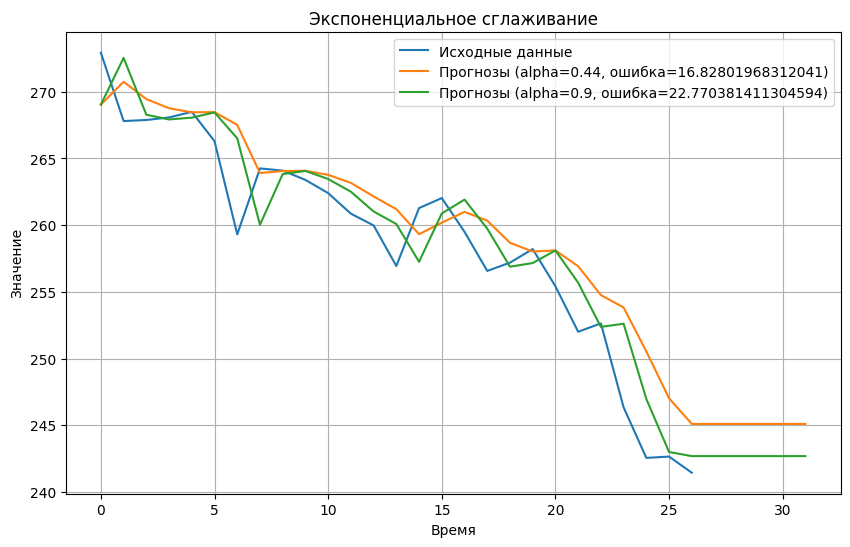

Проверка адекватности модели
    1. Проверка случайности остатков - Z-score: 1.73, Результат: True
    2. Проверка нормальности остатков (критерий хи-квадрат Пирсона) - p-value: 0.1884, Результат: True
    3. Проверка отсутствия автокорреляции (статистика Дарбина-Уотсона) - DW: 0.86, Результат: False
Итого: False


In [100]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# Функция экспоненциального сглаживания
def exponential_smoothing(data, alpha, steps=1):
    """
    Простое экспоненциальное сглаживание с возможностью прогноза на будущие шаги.

    :param data: Список наблюдений (временной ряд)
    :param alpha: Параметр сглаживания (0 < alpha <= 1)
    :param steps: Количество шагов для прогноза в будущее (по умолчанию 1)
    :return: Список прогнозов, включая прогнозы на будущие шаги
    """
    # Инициализация первого прогноза
    forecasts = [sum(data[0:5]) / 5]  # Первый прогноз равен среднему из первых 5-ти элементов

    # Вычисление прогнозов для исторических данных
    for t in range(1, len(data)):
        forecast = alpha * data[t - 1] + (1 - alpha) * forecasts[-1]
        forecasts.append(forecast)

    # Прогнозирование на будущие шаги
    last_forecast = forecasts[-1]  # Последний прогноз из исторических данных
    future_forecasts = []
    for step in range(steps):
        future_forecast = alpha * last_forecast + (1 - alpha) * last_forecast
        future_forecasts.append(future_forecast)
        last_forecast = future_forecast  # Обновляем последний прогноз
    forecasts.extend(future_forecasts)  # Добавляем прогнозы на будущие шаги
    return forecasts


# Пример использования
steps = 5  # Прогноз на 5 шагов вперед

# Поиск оптимального alpha
optimal_alpha, optimal_error = find_optimal_alpha(data_main, exponential_smoothing, steps=steps)
print(f"Оптимальное alpha: {optimal_alpha:.2f}")
print(f"Минимальная ошибка (MSE): {optimal_error:.4f}")

# Прогнозирование с оптимальным alpha
forecasts = exponential_smoothing(data_main, optimal_alpha, steps=steps)
forecasts_ = exponential_smoothing(data_main, 0.9, steps=steps) # TODO удалить

# Разделяем прогнозы на исторические и будущие
historical_forecasts = forecasts[:-steps]
future_forecasts = forecasts[-steps:]

# Подготовка данных для вывода и графиков
data_plot = {
    "Исходные данные": data_main,
    f"Прогнозы (alpha={optimal_alpha:.2f}, ошибка={optimal_error})": historical_forecasts + future_forecasts,
    f"Прогнозы (alpha=0.9, ошибка={calculate_error(data_main[-steps:], forecasts_[-steps:])})": forecasts_
}

print_data("Экспоненциальное сглаживание", data_plot, data_plot)

# Проверка адекватности модели
check_model_adequacy(data_main, historical_forecasts)

# ❌ 2) Алгоритм Хольта (альфа, бетта)

Оптимальные параметры (alpha, beta): (np.float64(0.1), np.float64(0.2))
Минимальная ошибка (MSE): 10.1713

Двойное экспоненциальное сглаживание:
Исходные данные: [272.92, 267.8, 267.88, 268.07, 268.49, 266.29, 259.31, 264.25, 264.09, 263.39, 262.4, 260.86, 259.98, 256.94, 261.28, 262.03, 259.5, 256.57, 257.19, 258.21, 255.42, 252.01, 252.64, 246.35, 242.56, 242.66, 241.45]
Прогнозы (alpha=0.10, beta=0.20, ошибка = 10.17128863747577): [272.92, np.float64(269.2773), np.float64(268.081), np.float64(267.0231), np.float64(266.1423), np.float64(265.1325), np.float64(263.4093), np.float64(262.3692), np.float64(261.4516), np.float64(260.5944), np.float64(259.7601), np.float64(258.8772), np.float64(258.0167), np.float64(256.9167), np.float64(256.4479), np.float64(256.2127), np.float64(255.8137), np.float64(255.1768), np.float64(254.7058), np.float64(254.454), np.float64(253.9677), np.float64(253.1499), np.float64(252.4666), np.float64(251.1004), np.float64(249.321), np.float64(247.5963), np.flo

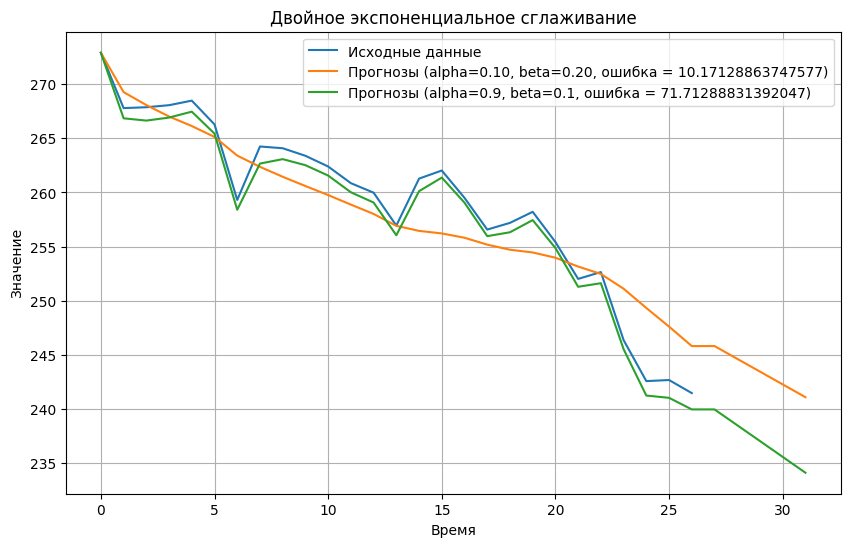

Проверка адекватности модели
    1. Проверка случайности остатков - Z-score: 2.68, Результат: False
    2. Проверка нормальности остатков (критерий хи-квадрат Пирсона) - p-value: 0.0143, Результат: False
    3. Проверка отсутствия автокорреляции (статистика Дарбина-Уотсона) - DW: 0.59, Результат: False
Итого: False


In [118]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
from itertools import product

# Функция двойного экспоненциального сглаживания (Holt's method)
def double_exponential_smoothing(data, alpha, beta, steps=1):
    """
    Двойное экспоненциальное сглаживание (метод Хольта).

    :param data: Список наблюдений (временной ряд)
    :param alpha: Параметр сглаживания уровня (0 < alpha <= 1)
    :param beta: Параметр сглаживания тренда (0 < beta <= 1)
    :param a1: Начальный уровень (intercept)
    :param a2: Начальный тренд (slope)
    :param steps: Количество шагов для прогноза в будущее (по умолчанию 1)
    :return: Список прогнозов
    """
    x = np.arange(len(data))
    y = np.array(data)

    # Линейная регрессия для начальных значений
    a2, a1 = np.polyfit(x, y, 1)

    # Инициализация уровней и трендов
    l = [a1]  # Уровень (начинается с a1)
    b = [a2]  # Тренд (начинается с a2)

    forecasts = []  # Список для хранения прогнозов

    # Шаг 1: Обучение на исторических данных
    for t in range(len(data)):
        if t == 0:
            # Первый прогноз равен первому значению
            forecasts.append(data[0])
        else:
            # Обновление уровня
            l_new = alpha * data[t] + (1 - alpha) * (l[-1] + b[-1])
            l.append(l_new)

            # Обновление тренда
            b_new = beta * (l[-1] - l[-2]) + (1 - beta) * b[-1]
            b.append(b_new)

            # Прогноз на текущий шаг
            forecast = l[-1] + b[-1]
            forecasts.append(forecast)

    # Шаг 2: Прогнозирование на будущие шаги
    future_forecasts = []
    last_level = l[-1]
    last_trend = b[-1]

    for step in range(1, steps + 1):
        # Прогноз на будущий шаг
        future_forecast = last_level + step * last_trend
        future_forecasts.append(future_forecast)

    return forecasts + future_forecasts

# Пример использования
steps = 5  # Прогноз на 5 шагов вперед

# Поиск оптимальных коэффициентов
optimal_params, optimal_error = find_optimal_alpha_betta(data_main, steps=steps, step_size=0.1)
print(f"Оптимальные параметры (alpha, beta): {optimal_params}")
print(f"Минимальная ошибка (MSE): {optimal_error:.4f}")

# Прогнозирование с оптимальными параметрами
forecasts = double_exponential_smoothing(data_main, optimal_params[0], optimal_params[1], steps=steps)

forecasts_ = double_exponential_smoothing(data_main, 0.9, 0.1, steps=steps) # TODO убрать

# Разделяем прогнозы на исторические и будущие
historical_forecasts = forecasts[:-steps]
future_forecasts = forecasts[-steps:]

# Подготовка данных для вывода и графиков
data_plot = {
    "Исходные данные": data_main,
    f"Прогнозы (alpha={optimal_params[0]:.2f}, beta={optimal_params[1]:.2f}, ошибка = {optimal_error})": forecasts,
    f"Прогнозы (alpha=0.9, beta={0.1}, ошибка = {calculate_error(data_main[-steps:], forecasts_[-steps:])})": forecasts_  # TODO убрать
}

print_data("Двойное экспоненциальное сглаживание", data_plot, data_plot)

# Проверка адекватности модели
check_model_adequacy(data_main, historical_forecasts)

# ❌ 3) Модель Брауна (альфа)

Оптимальное alpha: 0.44
Минимальная ошибка (MSE): 16.8280

Модель Брауна:
Исходные данные: [272.92, 267.8, 267.88, 268.07, 268.49, 266.29, 259.31, 264.25, 264.09, 263.39, 262.4, 260.86, 259.98, 256.94, 261.28, 262.03, 259.5, 256.57, 257.19, 258.21, 255.42, 252.01, 252.64, 246.35, 242.56, 242.66, 241.45]
Прогнозы (alpha=0.44, ошибка=16.82801968312041): [269.032, np.float64(270.7427), np.float64(269.4479), np.float64(268.758), np.float64(268.4553), np.float64(268.4706), np.float64(267.5111), np.float64(263.9026), np.float64(264.0555), np.float64(264.0707), np.float64(263.7712), np.float64(263.1679), np.float64(262.1524), np.float64(261.1965), np.float64(259.3237), np.float64(260.1845), np.float64(260.9965), np.float64(260.338), np.float64(258.6801), np.float64(258.0245), np.float64(258.1061), np.float64(256.9242), np.float64(254.762), np.float64(253.8283), np.float64(250.5378), np.float64(247.0276), np.float64(245.1059), np.float64(239.7175), np.float64(237.3466), np.float64(234.9758), n

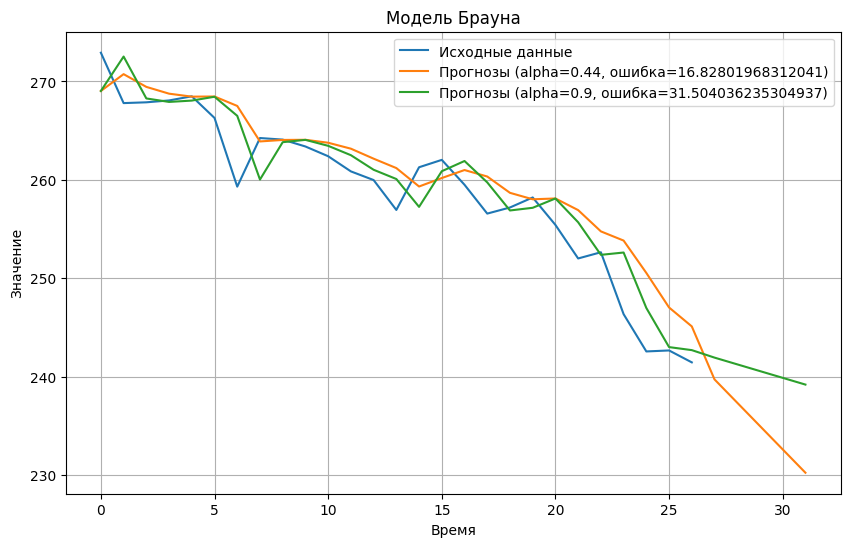

Проверка адекватности модели
    1. Проверка случайности остатков - Z-score: 1.73, Результат: True
    2. Проверка нормальности остатков (критерий хи-квадрат Пирсона) - p-value: 0.1884, Результат: True
    3. Проверка отсутствия автокорреляции (статистика Дарбина-Уотсона) - DW: 0.86, Результат: False
Итого: False


In [104]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# Функция модели Брауна
def brown_exponential_smoothing(data, alpha, steps=1):
    """
    Модель Брауна (двойное экспоненциальное сглаживание) с возможностью прогноза на будущие шаги.

    :param data: Список наблюдений (временной ряд)
    :param alpha: Параметр сглаживания (0 < alpha <= 1)
    :param steps: Количество шагов для прогноза в будущее (по умолчанию 1)
    :return: Список прогнозов, включая прогнозы на будущие шаги
    """
    # Инициализация первого прогноза
    forecasts = [sum(data[0:5]) / 5]  # Первый прогноз равен среднему из первых 5-ти элементов

    # Второй уровень сглаживания
    S2 = [forecasts[0]]  # Второе сглаживание также инициализируется тем же значением

    # Вычисление прогнозов для исторических данных
    for t in range(1, len(data)):
        # Первый уровень сглаживания
        forecast = alpha * data[t - 1] + (1 - alpha) * forecasts[-1]
        forecasts.append(forecast)

        # Второй уровень сглаживания
        S2.append(alpha * forecasts[-1] + (1 - alpha) * S2[-1])

    # Оценка уровня и тренда
    a_t = 2 * forecasts[-1] - S2[-1]
    b_t = (alpha / (1 - alpha)) * (forecasts[-1] - S2[-1])

    # Прогнозирование на будущие шаги
    future_forecasts = []
    for step in range(steps):
        future_forecast = a_t + b_t * (step + 1)
        future_forecasts.append(future_forecast)

    # Добавляем прогнозы на будущие шаги
    forecasts.extend(future_forecasts)

    return forecasts


# Пример использования
steps = 5  # Прогноз на 5 шагов вперед

# Поиск оптимального alpha
optimal_alpha, optimal_error = find_optimal_alpha(data_main, brown_exponential_smoothing, steps=steps)
print(f"Оптимальное alpha: {optimal_alpha:.2f}")
print(f"Минимальная ошибка (MSE): {optimal_error:.4f}")

# Прогнозирование с оптимальным alpha
forecasts = brown_exponential_smoothing(data_main, optimal_alpha, steps=steps)
forecasts_ = brown_exponential_smoothing(data_main, 0.9, steps=steps) # TODO удалить

# Разделяем прогнозы на исторические и будущие
historical_forecasts = forecasts[:-steps]
future_forecasts = forecasts[-steps:]

# Подготовка данных для вывода и графиков
data_plot = {
    "Исходные данные": data_main,
    f"Прогнозы (alpha={optimal_alpha:.2f}, ошибка={optimal_error})": historical_forecasts + future_forecasts,
    f"Прогнозы (alpha=0.9, ошибка={calculate_error(data_main[-steps:], forecasts_[-steps:])})": forecasts_
}

print_data("Модель Брауна", data_plot, data_plot)

# Проверка адекватности модели
check_model_adequacy(data_main, historical_forecasts)

# ✅ 4) Трёхпараметрическая модель Бокса—Дженкинса (альфа, бетта, гамма)

Оптимальные параметры: (np.float64(0.6), np.float64(0.9), np.float64(0.9))
Минимальная ошибка (MSE): 29.8252

Трехпараметрическая модель Бокса-Дженкинса:
Исходные данные: [272.92, 267.8, 267.88, 268.07, 268.49, 266.29, 259.31, 264.25, 264.09, 263.39, 262.4, 260.86, 259.98, 256.94, 261.28, 262.03, 259.5, 256.57, 257.19, 258.21, 255.42, 252.01, 252.64, 246.35, 242.56, 242.66, 241.45]
Прогнозы (alpha=0.60, beta=0.90, gamma=0.90, ошибка=29.825238347831363): [np.float64(270.5844), np.float64(272.274), np.float64(267.4619), np.float64(265.9613), np.float64(267.3729), np.float64(269.1949), np.float64(265.9893), np.float64(254.5077), np.float64(261.6471), np.float64(266.6055), np.float64(265.2749), np.float64(261.5613), np.float64(258.5207), np.float64(258.0898), np.float64(255.0586), np.float64(262.0494), np.float64(265.2782), np.float64(259.8514), np.float64(252.9694), np.float64(254.3871), np.float64(259.0068), np.float64(255.9526), np.float64(249.1365), np.float64(249.9413), np.float64(243

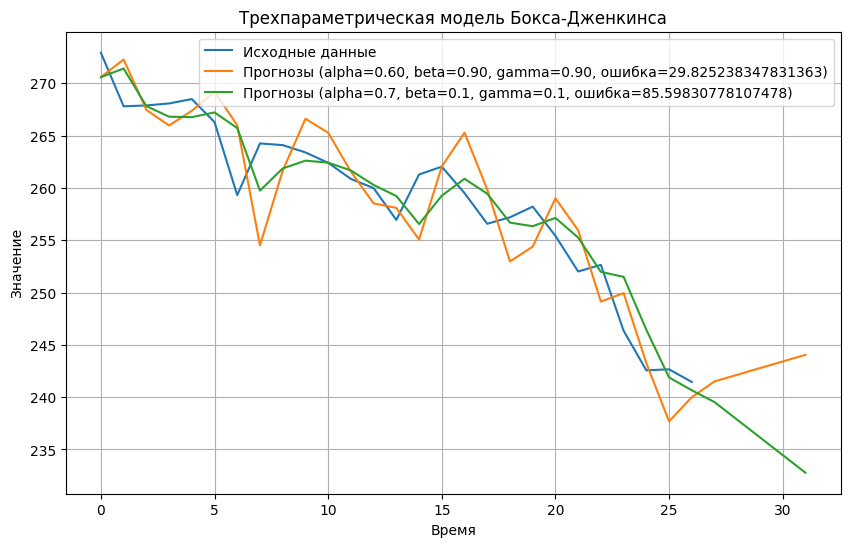

Проверка адекватности модели
    1. Проверка случайности остатков - Z-score: 1.26, Результат: True
    2. Проверка нормальности остатков (критерий хи-квадрат Пирсона) - p-value: 0.2480, Результат: True
    3. Проверка отсутствия автокорреляции (статистика Дарбина-Уотсона) - DW: 2.17, Результат: True
Итого: True


In [112]:
import numpy as np

# Функция модели с тремя коэффициентами
def box_jenkins_model(data, alpha, beta, gamma, steps=1):
    """
    Трёхпараметрическая модель с возможностью прогноза на будущие шаги.
    Использует уровень, тренд и адаптивность тренда.

    :param data: Список наблюдений (временной ряд)
    :param alpha: Параметр сглаживания уровня (0 < alpha <= 1)
    :param beta: Параметр сглаживания тренда (0 < beta <= 1)
    :param gamma: Параметр адаптивности тренда (0 < gamma <= 1)
    :param steps: Количество шагов для прогноза в будущее (по умолчанию 1)
    :return: Список прогнозов, включая прогнозы на будущие шаги
    """
    n = len(data)
    x = np.arange(len(data))
    y = np.array(data)

    # Линейная регрессия для начальных значений
    a2, a1 = np.polyfit(x, y, 1)


    # Инициализация уровней и тренда
    level = [a1] # Начальный уровень равен первому значению ряда
    trend = [a2] # Начальный тренд равен разнице между первыми двумя значениями

    # Вычисление уровней и тренда
    forecasts = []
    for t in range(n):
        # Прогноз для текущего момента времени
        forecast = level[-1] + trend[-1]
        forecasts.append(forecast)

        # Обновление уровня
        new_level = alpha * data[t] + (1 - alpha) * (level[-1] + trend[-1])
        level.append(new_level)

        # Обновление тренда
        new_trend = beta * (level[-1] - level[-2]) + (1 - beta) * trend[-1]
        trend.append(new_trend)

        # Адаптивность тренда (используем gamma)
        if t > 1:
            trend[-1] += gamma * (data[t] - level[-1])

    # Прогнозирование на будущие шаги
    future_forecasts = []
    for step in range(steps):
        future_forecast = level[-1] + (step + 1) * trend[-1]
        future_forecasts.append(future_forecast)

    # Добавляем прогнозы на будущие шаги
    forecasts.extend(future_forecasts)

    return forecasts

# Пример использования
steps = 5  # Прогноз на 5 шагов вперед

# Поиск оптимального alpha
optimal_params, optimal_error = find_optimal_alpha_beta_gamma(data_main, box_jenkins_model, steps=steps)
print(f"Оптимальные параметры: {optimal_params}")
print(f"Минимальная ошибка (MSE): {optimal_error:.4f}")

# Прогнозирование с оптимальными параметрами
alpha, beta, gamma = optimal_params
forecasts = box_jenkins_model(data_main, alpha, beta, gamma, steps=steps)
forecasts_ = box_jenkins_model(data_main, 0.7, 0.1, 0.1, steps=steps) # TODO удалить

# Разделяем прогнозы на исторические и будущие
historical_forecasts = forecasts[:-steps]
future_forecasts = forecasts[-steps:]

# Подготовка данных для вывода и графиков
data_plot = {
    "Исходные данные": data_main,
    f"Прогнозы (alpha={alpha:.2f}, beta={beta:.2f}, gamma={gamma:.2f}, ошибка={optimal_error})": historical_forecasts + future_forecasts,
    f"Прогнозы (alpha=0.7, beta=0.1, gamma=0.1, ошибка={calculate_error(data_main[-steps:], forecasts_[-steps:])})": forecasts_ # TODO удалить
}

print_data("Трехпараметрическая модель Бокса-Дженкинса", data_plot, data_plot)

# Проверка адекватности модели
check_model_adequacy(data_main, historical_forecasts)

# ❌ 5) Модель Тригга

Оптимальные параметры: (np.float64(0.30000000000000004), np.float64(0.4), np.float64(4.7))
Минимальная ошибка (MSE): 11.7044

Модель Тригга:
Исходные данные: [272.92, 267.8, 267.88, 268.07, 268.49, 266.29, 259.31, 264.25, 264.09, 263.39, 262.4, 260.86, 259.98, 256.94, 261.28, 262.03, 259.5, 256.57, 257.19, 258.21, 255.42, 252.01, 252.64, 246.35, 242.56, 242.66, 241.45]
Прогнозы (alpha=0.30, beta=0.40, control_limit=4.70, ошибка=11.704437743498596): [np.float64(272.92), np.float64(270.7696), np.float64(270.8032), np.float64(269.0505), np.float64(267.8823), np.float64(266.2135), np.float64(262.1229), np.float64(265.3888), np.float64(264.6077), np.float64(263.7048), np.float64(262.6192), np.float64(261.1861), np.float64(259.7743), np.float64(257.5339), np.float64(257.7171), np.float64(258.5879), np.float64(258.548), np.float64(257.4036), np.float64(256.7629), np.float64(256.7941), np.float64(255.814), np.float64(253.6485), np.float64(252.2006), np.float64(248.598), np.float64(248.1516), n

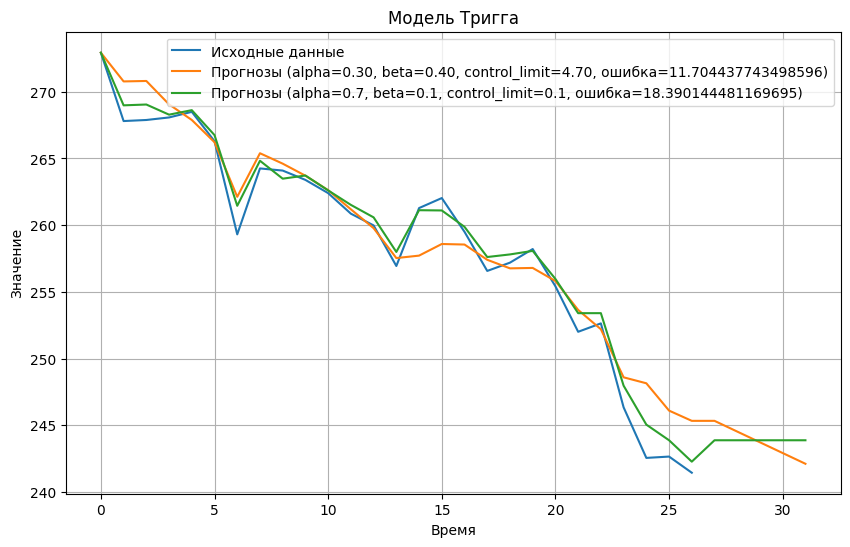

Проверка адекватности модели
    1. Проверка случайности остатков - Z-score: 1.26, Результат: True
    2. Проверка нормальности остатков (критерий хи-квадрат Пирсона) - p-value: 0.0501, Результат: True
    3. Проверка отсутствия автокорреляции (статистика Дарбина-Уотсона) - DW: 0.72, Результат: False
Итого: False


In [117]:
import numpy as np

# Функция модели Тригга с учетом тренда и прогнозом на будущие шаги
def trigg_model_with_trend_and_forecast(data, alpha, beta, control_limit, steps=1):
    """
    Адаптация экспоненциального сглаживания с учетом тренда и следящего контрольного сигнала (Модель Тригга).
    Включает прогноз на заданное количество шагов вперед.

    :param data: Список наблюдений (временной ряд)
    :param alpha: Параметр сглаживания уровня (0 < alpha <= 1)
    :param beta: Параметр сглаживания тренда (0 < beta <= 1)
    :param control_limit: Порог контроля для адаптации
    :param steps: Количество шагов для прогноза в будущее (по умолчанию 1)
    :return: Список прогнозов, включая прогнозы на будущие шаги
    """
    n = len(data)

    # Инициализация уровней и тренда
    level = np.zeros(n)
    trend = np.zeros(n)
    forecasts = np.zeros(n)

    # Начальные значения
    level[0] = data[0]
    trend[0] = 0  # Начальный тренд равен нулю
    forecasts[0] = data[0]

    # Основной цикл
    for t in range(1, n):
        # Обновление уровня
        level[t] = alpha * data[t] + (1 - alpha) * (level[t-1] + trend[t-1])

        # Обновление тренда
        trend[t] = beta * (level[t] - level[t-1]) + (1 - beta) * trend[t-1]

        # Прогноз на следующий шаг
        forecasts[t] = level[t] + trend[t]

        # Контрольный сигнал
        if abs(data[t] - forecasts[t-1]) > control_limit:
            # Адаптация уровня и тренда
            level[t] = forecasts[t-1]  # Корректировка уровня
            trend[t] = 0              # Сброс тренда

    # Прогнозирование на будущие шаги
    future_forecasts = []
    last_level = level[-1]
    last_trend = trend[-1]

    for step in range(steps):
        future_forecast = last_level + (step + 1) * last_trend
        future_forecasts.append(future_forecast)

    # Добавляем прогнозы на будущие шаги
    forecasts = np.append(forecasts, future_forecasts)

    return forecasts

# Пример использования
steps = 5  # Прогноз на 5 шагов вперед

# Поиск оптимального alpha
optimal_params, optimal_error = find_optimal_alpha_beta_gamma(data_main, trigg_model_with_trend_and_forecast, steps=steps, control_limit_max=5)
print(f"Оптимальные параметры: {optimal_params}")
print(f"Минимальная ошибка (MSE): {optimal_error:.4f}")

# Прогнозирование с оптимальными параметрами
alpha, beta, control_limit = optimal_params
forecasts = trigg_model_with_trend_and_forecast(data_main, alpha, beta, control_limit, steps=steps)
forecasts_ = trigg_model_with_trend_and_forecast(data_main, 0.7, 0.1, 0.1, steps=steps) # TODO удалить

# Разделяем прогнозы на исторические и будущие
historical_forecasts = forecasts[:-steps]
future_forecasts = forecasts[-steps:]

# Подготовка данных для вывода и графиков
data_plot = {
    "Исходные данные": data_main,
    f"Прогнозы (alpha={alpha:.2f}, beta={beta:.2f}, control_limit={control_limit:.2f}, ошибка={optimal_error})": forecasts,
    f"Прогнозы (alpha=0.7, beta=0.1, control_limit=0.1, ошибка={calculate_error(data_main[-steps:], forecasts_[-steps:])})": forecasts_ # TODO удалить
}

print_data("Модель Тригга", data_plot, data_plot)

# Проверка адекватности модели
check_model_adequacy(data_main, historical_forecasts)

# Селекционная модель на основе предыдущих 5-ти методах

In [148]:
import numpy as np
from itertools import product

# Объединенная функция: выбор модели и построение прогноза
def selection_and_forecast(data, steps=1, step_size_alpha=0.1, step_size_beta=0.1, step_size_gamma=0.1, step_size_limit=0.5):
    """
    Выбирает лучшую модель для каждого шага и строит прогнозы.

    :param data: Список данных (временной ряд)
    :param steps: Количество шагов для прогноза в будущее
    :param step_size_alpha: Шаг перебора для alpha (по умолчанию 0.1)
    :param step_size_beta: Шаг перебора для beta (по умолчанию 0.1)
    :param step_size_gamma: Шаг перебора для gamma (по умолчанию 0.1)
    :param step_size_limit: Шаг перебора для control_limit (по умолчанию 0.5)
    :return: Лучшие модели, их параметры, ошибки, полные прогнозы (исторические + будущие)
    """
    models = {
        1: ("Exponential Smoothing", exponential_smoothing),
        2: ("Holt's Linear Trend", double_exponential_smoothing),
        3: ("Brown's Model", brown_exponential_smoothing),
        4: ("Box-Jenkins Model", box_jenkins_model),
        5: ("Trigg's Model", trigg_model_with_trend_and_forecast)
    }

    n = len(data)  # Длина исходных данных
    best_models = []  # Лучшая модель для каждого шага
    best_params_list = []  # Параметры для каждой модели
    errors = []  # Ошибки для каждого шага
    historical_forecasts = [None] * n  # Исторические прогнозы
    future_forecasts = []  # Прогнозы на будущие шаги

    # Перебор шагов прогноза (для исторических данных)
    for t in range(1, n):
        print(f"\nHistorical Step {t}:")
        min_error_step = float('inf')
        best_model_step = None
        best_params_step = None
        best_forecast_step = None

        # Перебор всех моделей
        for model_number, (model_name, model_func) in models.items():
            if model_name == "Exponential Smoothing":
                for alpha in np.arange(0 + step_size_alpha, 1, step_size_alpha):
                    forecasts = model_func(data[:t], alpha, steps=1)[-1]  # Прогноз на текущий шаг
                    actual = data[t]
                    error = calculate_error([actual], [forecasts])
                    if error < min_error_step:
                        min_error_step = error
                        best_model_step = model_number
                        best_params_step = (alpha,)
                        best_forecast_step = forecasts
            elif model_name == "Holt's Linear Trend":
                for alpha in np.arange(0 + step_size_alpha, 1, step_size_alpha):
                    for beta in np.arange(0 + step_size_beta, 1, step_size_beta):
                        forecasts = model_func(data[:t], alpha, beta, steps=1)[-1]  # Прогноз на текущий шаг
                        actual = data[t]
                        error = calculate_error([actual], [forecasts])
                        if error < min_error_step:
                            min_error_step = error
                            best_model_step = model_number
                            best_params_step = (alpha, beta)
                            best_forecast_step = forecasts
            elif model_name == "Brown's Model":
                for alpha in np.arange(0 + step_size_alpha, 1, step_size_alpha):
                    forecasts = model_func(data[:t], alpha, steps=1)[-1]  # Прогноз на текущий шаг
                    actual = data[t]
                    error = calculate_error([actual], [forecasts])
                    if error < min_error_step:
                        min_error_step = error
                        best_model_step = model_number
                        best_params_step = (alpha,)
                        best_forecast_step = forecasts
            elif model_name == "Box-Jenkins Model":
                for alpha in np.arange(0 + step_size_alpha, 1, step_size_alpha):
                    for beta in np.arange(0 + step_size_beta, 1, step_size_beta):
                        for gamma in np.arange(0 + step_size_gamma, 1, step_size_gamma):
                            forecasts = model_func(data[:t], alpha, beta, gamma, steps=1)[-1]  # Прогноз на текущий шаг
                            actual = data[t]
                            error = calculate_error([actual], [forecasts])
                            if error < min_error_step:
                                min_error_step = error
                                best_model_step = model_number
                                best_params_step = (alpha, beta, gamma)
                                best_forecast_step = forecasts
            elif model_name == "Trigg's Model":
                for alpha in np.arange(0 + step_size_alpha, 1, step_size_alpha):
                    for beta in np.arange(0 + step_size_beta, 1, step_size_beta):
                        for control_limit in np.arange(0 + step_size_limit, 5, step_size_limit):
                            forecasts = model_func(data[:t], alpha, beta, control_limit, steps=1)[-1]  # Прогноз на текущий шаг
                            actual = data[t]
                            error = calculate_error([actual], [forecasts])
                            if error < min_error_step:
                                min_error_step = error
                                best_model_step = model_number
                                best_params_step = (alpha, beta, control_limit)
                                best_forecast_step = forecasts

        # Сохраняем результаты для текущего шага
        best_models.append(best_model_step)
        best_params_list.append(best_params_step)
        errors.append(min_error_step)
        historical_forecasts[t] = best_forecast_step
        print(f" Historical Step {t}: Модель={best_model_step}, Параметры={best_params_step}, Прогноз={best_forecast_step:.4f}, Ошибка={min_error_step:.4f}")

    # Прогнозирование на будущие шаги
    print("\nFuture Forecasting:")
    for step in range(steps):
        min_error_step = float('inf')
        best_model_step = None
        best_params_step = None
        best_forecast_step = None

        # Перебор всех моделей
        for model_number, (model_name, model_func) in models.items():
            if model_name == "Exponential Smoothing":
                for alpha in np.arange(0 + step_size_alpha, 1, step_size_alpha):
                    forecasts = model_func(data, alpha, steps=step + 1)[-1]  # Прогноз на следующий шаг
                    error = min_error_step  # Для будущих шагов ошибка не вычисляется
                    if error <= min_error_step:
                        min_error_step = error
                        best_model_step = model_number
                        best_params_step = (alpha,)
                        best_forecast_step = forecasts
            elif model_name == "Holt's Linear Trend":
                for alpha in np.arange(0 + step_size_alpha, 1, step_size_alpha):
                    for beta in np.arange(0 + step_size_beta, 1, step_size_beta):
                        forecasts = model_func(data, alpha, beta, steps=step + 1)[-1]  # Прогноз на следующий шаг
                        error = min_error_step  # Для будущих шагов ошибка не вычисляется
                        if error <= min_error_step:
                            min_error_step = error
                            best_model_step = model_number
                            best_params_step = (alpha, beta)
                            best_forecast_step = forecasts
            elif model_name == "Brown's Model":
                for alpha in np.arange(0 + step_size_alpha, 1, step_size_alpha):
                    forecasts = model_func(data, alpha, steps=step + 1)[-1]  # Прогноз на следующий шаг
                    error = min_error_step  # Для будущих шагов ошибка не вычисляется
                    if error <= min_error_step:
                        min_error_step = error
                        best_model_step = model_number
                        best_params_step = (alpha,)
                        best_forecast_step = forecasts
            elif model_name == "Box-Jenkins Model":
                for alpha in np.arange(0 + step_size_alpha, 1, step_size_alpha):
                    for beta in np.arange(0 + step_size_beta, 1, step_size_beta):
                        for gamma in np.arange(0 + step_size_gamma, 1, step_size_gamma):
                            forecasts = model_func(data, alpha, beta, gamma, steps=step + 1)[-1]  # Прогноз на следующий шаг
                            error = min_error_step  # Для будущих шагов ошибка не вычисляется
                            if error <= min_error_step:
                                min_error_step = error
                                best_model_step = model_number
                                best_params_step = (alpha, beta, gamma)
                                best_forecast_step = forecasts
            elif model_name == "Trigg's Model":
                for alpha in np.arange(0 + step_size_alpha, 1, step_size_alpha):
                    for beta in np.arange(0 + step_size_beta, 1, step_size_beta):
                        for control_limit in np.arange(0 + step_size_limit, 5, step_size_limit):
                            forecasts = model_func(data, alpha, beta, control_limit, steps=step + 1)[-1]  # Прогноз на следующий шаг
                            error = min_error_step  # Для будущих шагов ошибка не вычисляется
                            if error <= min_error_step:
                                min_error_step = error
                                best_model_step = model_number
                                best_params_step = (alpha, beta, control_limit)
                                best_forecast_step = forecasts

        # Сохраняем результаты для текущего будущего шага
        future_forecasts.append(best_forecast_step)
        print(f" Future Step {step + 1}: Модель={best_model_step}, Параметры={best_params_step}, Прогноз={best_forecast_step:.4f}")

    # Полный прогноз
    full_forecasts = historical_forecasts + future_forecasts

    return best_models, best_params_list, errors, full_forecasts

In [149]:
# Исходные данные
steps = 10

# Выбор модели и построение прогноза
best_models, best_params_list, errors, forecasts = selection_and_forecast(data_main, steps=steps)

# Вывод результатов
print("\nИтоговые результаты:")
for step in range(steps):
    print(f"Шаг {step + 1}: Модель {best_models[step]}, Параметры={best_params_list[step]}, Прогноз={forecasts[step]:.4f}, Ошибка={errors[step]:.4f}")

# Разделяем прогнозы на исторические и будущие
historical_forecasts = forecasts[:-steps]
future_forecasts = forecasts[-steps:]

data_plot = {
    "Исходные данные": data_main,
    f"Прогнозы": forecasts
}

print_data("Селекционная модель", data_plot, data_plot)

# Проверка адекватности модели
check_model_adequacy(data_main, forecasts)


Historical Step 1:


LinAlgError: SVD did not converge in Linear Least Squares